In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install jiwer
!pip install --upgrade nltk
!pip install --upgrade pip
!pip install datasets gdown --no-cache transformers sentencepiece sacrebleu evaluate accelerate -U
!pip install --upgrade tensorflow
#!gdown 173lmjt9TgTYXFR4ySls5xkIjedDfnSH-UK7jxJSMus0
#!gdown 1kysE0WewbvcsRVKsm72v6-AgbgflGZ3hh7NoxIB6zZI

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.4 MB/s eta 0:00:0000:010:01
  Attempting uninstall: nltk
    Found existing installation: nltk 3.2.4
    Uninstalling nltk-3.2.4:
      Successfully uninstalled nltk-3.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.8.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.5 MB/s eta 0:00:0000:010:01
  Attempting uninstall: pip
    Found existing installation: pip 23.3.2
    Uninstalling pip-23.3.2:
      Successfully uninstalled pip-23.3.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 196.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np

data_original = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/0_MY_DATA/0_HUGE_DATA/FINAL_DATA/_100_TN_Oversampled_Final_Data.csv", encoding ='utf-16')
data_original

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Sentence_ID,Token_ID,CLASS,BEFORE,AFTER,LABEL
0,121958,121958,121958,128581,1,BNG_TEXT,স্ময়ের,স্ময়ের,0
1,131932,131932,131932,145310,9,BNG_TEXT,নিরুপন,নিরুপন,0
2,365838,365838,365838,804112,5,BNG_TEXT,বেশ্যাগামীরা,বেশ্যাগামীরা,0
3,259178,259178,259178,350542,1,BNG_TEXT,ফুডে,ফুডে,0
4,110268,110268,110268,111988,15,BNG_TEXT,আকরামকে,আকরামকে,0
...,...,...,...,...,...,...,...,...,...
2595,744486,744486,744486,1822479,1,EMOZI,;-),;-),25
2596,737641,737641,737641,1558978,9,EMOZI,:-(,:-(,25
2597,707933,707933,707933,141400,3,EMOZI,;),;),25
2598,737641,737641,737641,1558978,9,EMOZI,:-(,:-(,25


In [ ]:
data_original[data_original["CLASS"]=="ROMAN_NUM"]

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,Sentence_ID,Token_ID,CLASS,BEFORE,AFTER,LABEL
1400,1982648,1982648,1982648,0,0,ROMAN_NUM,DCCCLVIII,DCCCLVIII,14
1401,1985560,1985560,1985560,0,0,ROMAN_NUM,MMMDCCLXX,MMMDCCLXX,14
1402,1984880,1984880,1984880,0,0,ROMAN_NUM,MMMXC,MMMXC,14
1403,1982254,1982254,1982254,0,0,ROMAN_NUM,CDLXIV,CDLXIV,14
1404,1986214,1986214,1986214,0,0,ROMAN_NUM,MMMMCDXXIV,MMMMCDXXIV,14
...,...,...,...,...,...,...,...,...,...
1495,1986663,1986663,1986663,0,0,ROMAN_NUM,MMMMDCCCLXXIII,MMMMDCCCLXXIII,14
1496,1984892,1984892,1984892,0,0,ROMAN_NUM,MMMCII,MMMCII,14
1497,1986386,1986386,1986386,0,0,ROMAN_NUM,MMMMDXCVI,MMMMDXCVI,14
1498,1984242,1984242,1984242,0,0,ROMAN_NUM,MMCDLII,MMCDLII,14


In [2]:
import pandas as pd
import numpy as np

data_original = pd.read_csv("/kaggle/input/parallel-sentence/228228_emotional parallel corpus.csv", encoding ='utf-16')[["BEFORE SENTENCE","AFTER SENTENCE"]]
data_original =  data_original[1000:1300]
data =pd.DataFrame()
data["BEFORE"] = data_original["BEFORE SENTENCE"]
data["AFTER"] = data_original["AFTER SENTENCE"]
data = data.reset_index(drop=True)
data

,BEFORE,AFTER
0,"ওহ , ভাল , আমি খুব যে শুনতে খুশি .","ওহ , ভাল , আমি খুব যে শুনতে খুশি ."
1,"এ ছাড়া , এই অধ্যায়ে আরও অনেক ব্যক্তির বিষয়ে উল...","এ ছাড়া , এই অধ্যায়ে আরও অনেক ব্যক্তির বিষয়ে উল..."
2,"আমি জ্যাক স্প্যারো না , হলে খুশিই হতাম এই কোর্ট এ","আমি জ্যাক স্প্যারো না , হলে খুশিই হতাম এই কোর্ট এ"
3,"তবে , যোনা এতে খুশি হননি ।","তবে , যোনা এতে খুশি হননি ।"
4,আপনাদেরকে আবার দেখে খুশি হয়েছি ।,আপনাদেরকে আবার দেখে খুশি হয়েছি ।
...,...,...
295,স্তব - বলি যা যিহোবাকে খুশি করে,স্তব - বলি যা যিহোবাকে খুশি করে
296,"( ২ পিতর ১ : ১৯ ) আমরা মনেপ্রাণে চাই , বাইবেল ...","( দুই পিতর এক : উনিশ ) আমরা মনেপ্রাণে চাই , বা..."
297,"তবে , আপনি এটা জেনে খুশি হবেন যে , এই ভাই ও বো...","তবে , আপনি এটা জেনে খুশি হবেন যে , এই ভাই ও বো..."
298,"এটা সম্পূর্ণ পরিবর্তনের - স্বার্থপর , জাগতিক জ...","এটা সম্পূর্ণ পরিবর্তনের - স্বার্থপর , জাগতিক জ..."


In [3]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(data, test_size=0.2, shuffle=True, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
import pandas as pd

# Assuming 'BEFORE' column contains string values
train_df['BEFORE'] = train_df['BEFORE'].astype(str)
train_df['AFTER'] = train_df['AFTER'].astype(str)
val_df['BEFORE'] = val_df['BEFORE'].astype(str)
val_df['AFTER'] = val_df['AFTER'].astype(str)
from datasets import Dataset

ds_train = Dataset.from_pandas(train_df)
ds_eval = Dataset.from_pandas(val_df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


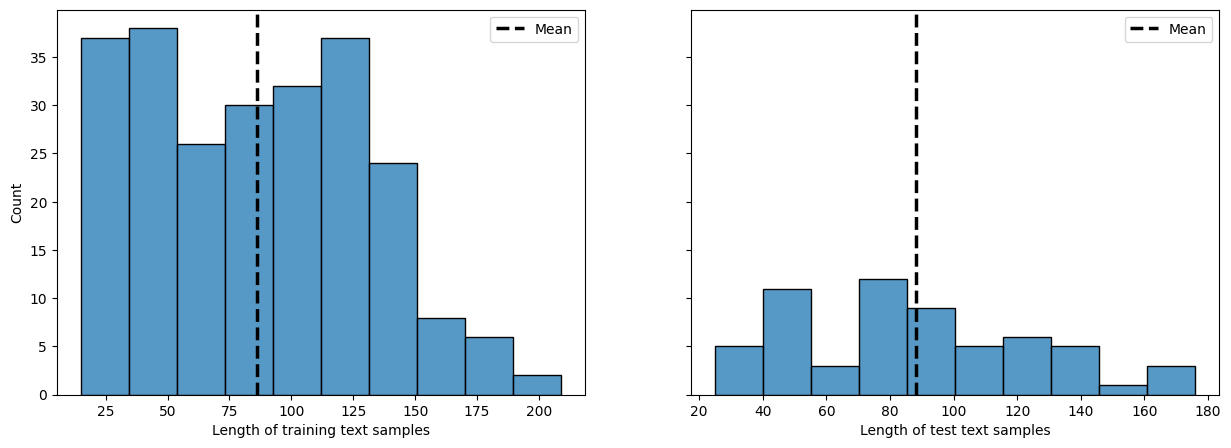

In [4]:
!pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

train_lengths = train_df["BEFORE"].str.len()
sns.histplot(ax=axes[0], data=train_lengths, bins=10).set(xlabel="Length of training text samples")
axes[0].axvline(train_lengths.mean(), c="k", ls="--", lw=2.5, label="Mean")
axes[0].legend()

test_lengths = val_df["BEFORE"].str.len()
sns.histplot(ax=axes[1], data=test_lengths, bins=10).set(xlabel="Length of test text samples")
axes[1].axvline(test_lengths.mean(), c="k", ls="--", lw=2.5, label="Mean")
axes[1].legend()

plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


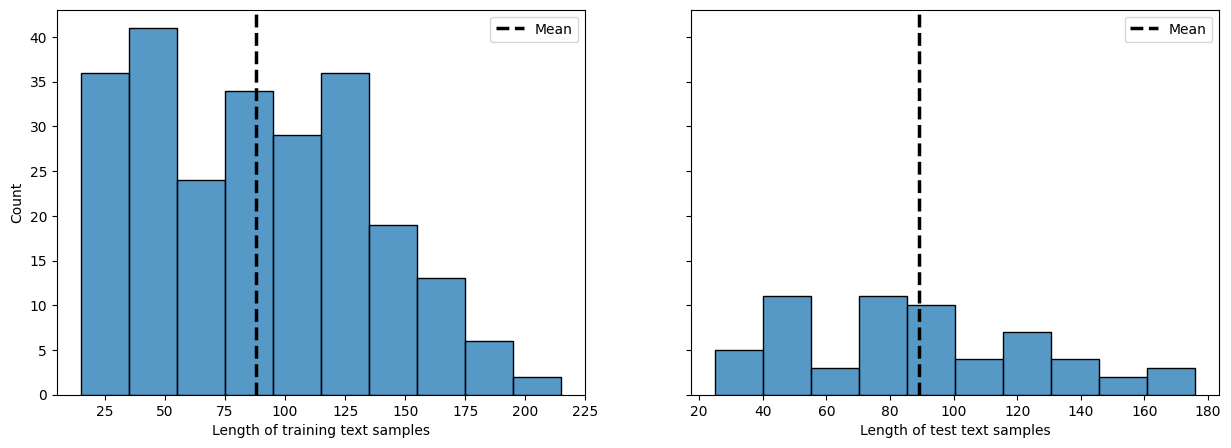

In [5]:
!pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

train_lengths = train_df["AFTER"].str.len()
sns.histplot(ax=axes[0], data=train_lengths, bins=10).set(xlabel="Length of training text samples")
axes[0].axvline(train_lengths.mean(), c="k", ls="--", lw=2.5, label="Mean")
axes[0].legend()

test_lengths = val_df["AFTER"].str.len()
sns.histplot(ax=axes[1], data=test_lengths, bins=10).set(xlabel="Length of test text samples")
axes[1].axvline(test_lengths.mean(), c="k", ls="--", lw=2.5, label="Mean")
axes[1].legend()

plt.show()

In [7]:
data['BEFORE'] = data['BEFORE'].astype(str)
data['AFTER'] = data['AFTER'].astype(str)

res = {"translation":[]}
#print(type(data))
print(data.columns)
for row in range(len(data)):
  if data["BEFORE"][row] != "" and data["AFTER"][row] != "":
    res["translation"].append({"BEFORE": data["BEFORE"][row],"AFTER" :data["AFTER"][row]})

Index(['BEFORE', 'AFTER'], dtype='object')


In [9]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

In [10]:
data = Dataset.from_pandas(pd.DataFrame(res))
data

Dataset({
    features: ['translation'],
    num_rows: 300
})

In [11]:
data = data.train_test_split(test_size=0.2)

In [12]:
data

DatasetDict({
    train: Dataset({
        features: ['translation'],
        num_rows: 240
    })
    test: Dataset({
        features: ['translation'],
        num_rows: 60
    })
})

In [13]:
data["train"][1]

{'translation': {'AFTER': "( হিতোপদেশ ছয় : ষোল থেকে উনিশ ) তাই ঈশ্বরকে খুশি করার জন্য আমাদের যে ইচ্ছা , তা আমাদেরকে ' যাহা মিথ্যা , তাহা ত্যাগ করিয়া সত্য আলাপ করিতে ' প্রেরণা দেয় ।",
  'BEFORE': "( হিতোপদেশ ৬ : ১৬-১৯ ) তাই ঈশ্বরকে খুশি করার জন্য আমাদের যে ইচ্ছা , তা আমাদেরকে ' যাহা মিথ্যা , তাহা ত্যাগ করিয়া সত্য আলাপ করিতে ' প্রেরণা দেয় ।"}}

In [14]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM,Seq2SeqTrainingArguments,Seq2SeqTrainer
checkpoint = "csebuetnlp/banglat5"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

2024-03-08 03:14:56.178938: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-08 03:14:56.179003: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-08 03:14:56.180530: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


tokenizer_config.json:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/1.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.79k [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [16]:
source_lang = "BEFORE"
target_lang = "AFTER"
prefix = "Unnormalized Text to Normalaized Text:"

In [17]:
def preprocess_function(examples):
    inputs = [prefix + example[source_lang] for example in examples["translation"]]
    targets = [example[target_lang] for example in examples["translation"]]
    model_inputs = tokenizer(inputs, text_target=targets, max_length=128, truncation=True)
    return model_inputs

In [18]:
tokenized_books = data.map(preprocess_function, batched = True)

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

In [19]:
!pip install evaluate sacrebleu
from transformers import DataCollatorForSeq2Seq
import evaluate
import numpy as np
metric = evaluate.load("sacrebleu")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [20]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=checkpoint)

In [21]:
def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

In [22]:
# Garbage Collector - use it like gc.collect()
import gc
gc.collect()

112

In [23]:
# ! pip install jiwer
# !pip install --upgrade nltk

import numpy as np
import jiwer
from datasets import load_metric
from nltk.translate.meteor_score import meteor_score

wer_metric = load_metric("wer")
meteor_metric = load_metric("meteor")

# Define the compute_metrics function
def compute_metrics(eval_preds):
    preds, labels = eval_preds
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = trainer.tokenizer.batch_decode(preds, skip_special_tokens=True)

    labels = np.where(labels != -100, labels, trainer.tokenizer.pad_token_id)
    decoded_labels = trainer.tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    result = metric.compute(predictions=decoded_preds, references=decoded_labels)
    metrics = {"bleu": result["score"]}

    prediction_lens = [np.count_nonzero(pred != trainer.tokenizer.pad_token_id) for pred in preds]
    metrics["gen_len"] = np.mean(prediction_lens)

    pred_wer = wer_metric.compute(predictions=decoded_preds, references=decoded_labels)
    metrics["wer"] = pred_wer

    # Compute Character Error Rate (CER)
    meteor_score_val = meteor_metric.compute(predictions=decoded_preds, references=decoded_labels)["meteor"]
    metrics["meteor"] = meteor_score_val

    # Compute accuracy
    correct_predictions = sum(p == l for p, l in zip(decoded_preds, decoded_labels))
    total_predictions = len(decoded_preds)
    accuracy = correct_predictions / total_predictions
    metrics["accuracy"] = accuracy

    # metrics["training_loss"] = np.mean(training_history["training_loss"])
    # metrics["validation_loss"] = np.mean(training_history["validation_loss"])

    metrics = {k: round(v, 5) for k, v in metrics.items()}
    return metrics

/tmp/ipykernel_34/338746923.py:9: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  wer_metric = load_metric("wer")
/opt/conda/lib/python3.10/site-packages/datasets/load.py:756: FutureWarning: The repository for wer contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.18.0/metrics/wer/wer.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/datasets/load.py:756: FutureWarning: The repository for meteor contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.18.0/metrics/meteor/meteor.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


In [24]:
training_args = Seq2SeqTrainingArguments(
    output_dir="/content/model",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    save_steps=2500,
    eval_steps=2500,
    logging_steps=2500,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=100,
    predict_with_generate=True,
    fp16=False,
    push_to_hub=False,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_books["train"],
    eval_dataset=tokenized_books["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    #callbacks=[logging_callback]
)

history = trainer.train()

# Access the training history after training is complete
# print(training_history)

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

  ········································


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


OutOfMemoryError: Caught OutOfMemoryError in replica 0 on device 0.
Original Traceback (most recent call last):
  File "/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py", line 85, in _worker
    output = module(*input, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1518, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1527, in _call_impl
    return forward_call(*args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/transformers/models/t5/modeling_t5.py", line 1748, in forward
    decoder_outputs = self.decoder(
  File "/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1518, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/opt/conda/lib/python3.10/site-packages/torch/nn/modules/module.py", line 1527, in _call_impl
    return forward_call(*args, **kwargs)
  Fi

In [ ]:
# Define a custom callback to log metrics
from transformers import  TrainerCallback

class LoggingCallback(TrainerCallback):
    def __init__(self):
        super().__init__()

    def on_epoch_end(self, args, state, control, model=None, tokenizer=None, **kwargs):
        if model is not None and tokenizer is not None:
            eval_metrics = trainer.evaluate()  # Remove eval_dataloader argument
            eval_preds = trainer.predict(tokenized_books["test"])
            eval_metrics = compute_metrics(eval_preds)
            training_history["eval_metrics"].append(eval_metrics)

            # Log metrics
            epoch_metrics = {
                "Epoch": state.epoch,
                "Training Loss": eval_metrics["eval_training_loss"],
                "Validation Loss": eval_metrics["eval_validation_loss"],
                "BLEU": eval_metrics["bleu"],
                "Gen Len": eval_metrics["gen_len"],
                "wer":eval_metrics["wer"]
            }
            self.log_df = self.log_df.append(epoch_metrics, ignore_index=True)
            self.log_df.to_csv("/content/logs/metrics_log.csv", index=False)

# Initialize logging callback
logging_callback = LoggingCallback()

In [ ]:
# Define a custom callback to log metrics
from transformers import TrainerCallback

# Initialize an empty dictionary to store training history
training_history = {"epoch": [], "training_loss": [], "validation_loss": [], "bleu": [], "gen_len": [], "wer": []}

# Define a callback to log training metrics
class LoggingCallback(TrainerCallback):
    def __init__(self):
        super().__init__()

    def on_epoch_end(self, args, state, control, model=None, tokenizer=None, **kwargs):
        if model is not None and tokenizer is not None:
            eval_metrics = trainer.evaluate()  # Remove eval_dataloader argument
            print(eval_metrics)
            eval_preds = trainer.predict(tokenized_books["test"])
            eval_metrics = compute_metrics(eval_preds)
            training_history["epoch"].append(state.epoch)
            training_history["training_loss"].append(eval_metrics["eval_training_loss"])
            training_history["validation_loss"].append(eval_metrics["eval_validation_loss"])
            training_history["bleu"].append(eval_metrics["eval_bleu"])
            training_history["gen_len"].append(eval_metrics["eval_gen_len"])
            training_history["wer"].append(eval_metrics["eval_wer"])

# Initialize logging callback
logging_callback = LoggingCallback()


In [ ]:
trainer.evaluate()

/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1178: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.

  warnings.warn(


{'eval_loss': 6.445892810821533,
 'eval_bleu': 5.51098,
 'eval_gen_len': 19.0,
 'eval_wer': 0.97973,
 'eval_meteor': 0.0972,
 'eval_accuracy': 0.0,
 'eval_runtime': 1.1632,
 'eval_samples_per_second': 8.597,
 'eval_steps_per_second': 0.86,
 'epoch': 100.0}

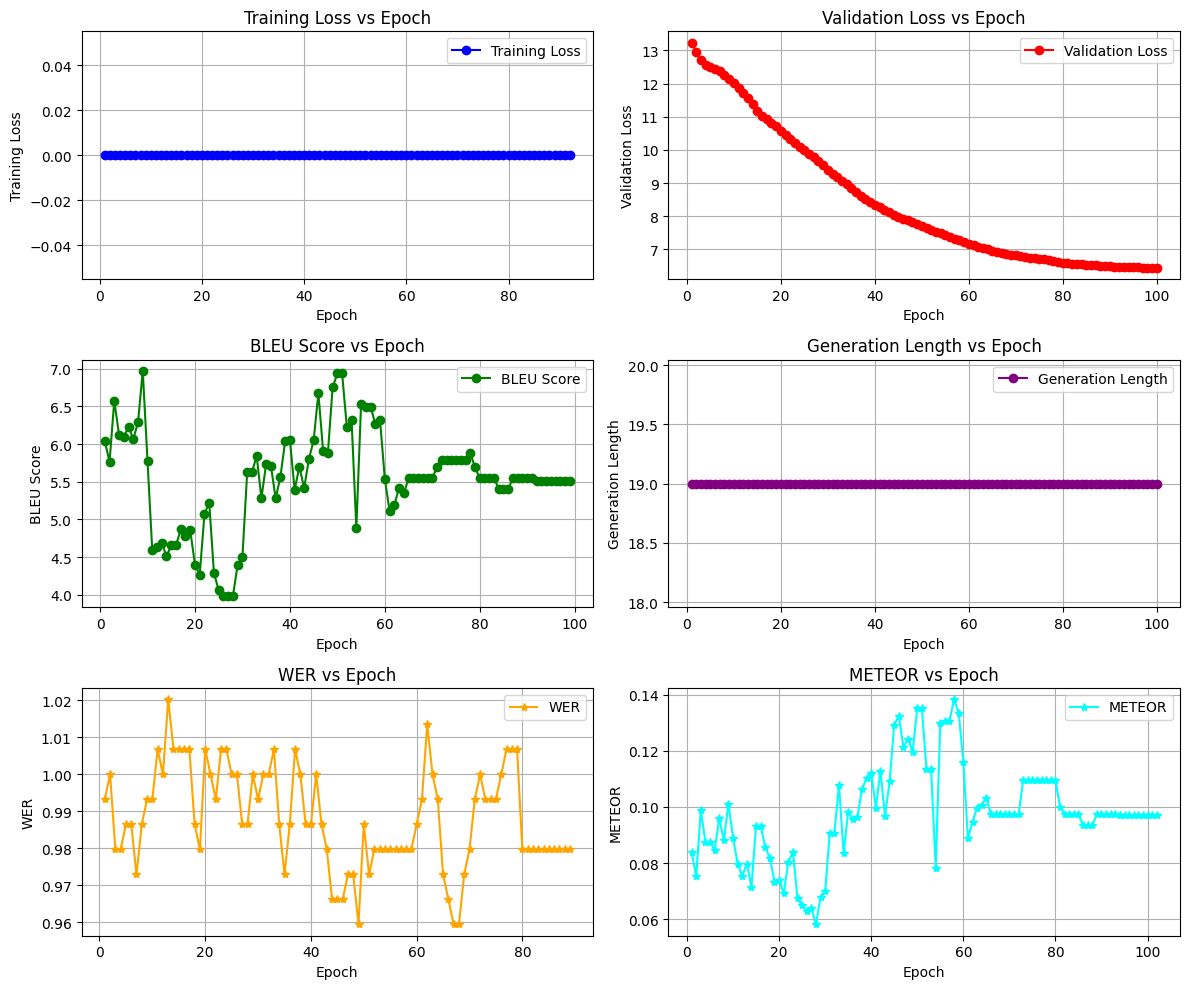

In [ ]:
import matplotlib.pyplot as plt

# Data from the table
epochs = list(range(1, 101))
training_loss = [
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000,
        0.000000, 0.000000, 0.000000, 0.000000
    ]

validation_loss = [
        13.237553, 12.955347, 12.703231, 12.547425, 12.499574, 12.43361, 12.366134, 12.264629, 12.143401, 12.030176,
        11.880878, 11.707122, 11.55989, 11.380849, 11.168123, 11.014344, 10.92888, 10.826754, 10.713899, 10.578095,
        10.45056, 10.325273, 10.203171, 10.101435, 9.991484, 9.888519, 9.77907, 9.671919, 9.541319, 9.402632,
        9.284304, 9.174234, 9.069185, 8.96773, 8.845091, 8.724755, 8.61579, 8.519762, 8.431807, 8.352264, 8.267287,
        8.195823, 8.11667, 8.048302, 7.988024, 7.928475, 7.878616, 7.817125, 7.756447, 7.699389, 7.642084, 7.588684,
        7.536062, 7.485674, 7.432137, 7.380929, 7.324822, 7.271383, 7.223921, 7.168557, 7.124597, 7.083137, 7.037529,
        6.997862, 6.962098, 6.927645, 6.900388, 6.874321, 6.844132, 6.820465, 6.796272, 6.774827, 6.756104, 6.739365,
        6.718689, 6.697114, 6.674006, 6.647861, 6.624754, 6.605322, 6.58708, 6.572168, 6.559698, 6.547028, 6.535276,
        6.523966, 6.515491, 6.507042, 6.499115, 6.491199, 6.484098, 6.478211, 6.473139, 6.46702, 6.460629, 6.455535,
        6.451606, 6.448807, 6.446825, 6.445893]

bleu = [6.0377, 5.7642, 6.57359, 6.12357, 6.09566, 6.22807, 6.06636, 6.28653, 6.96887, 5.77619, 4.59377, 4.63369,
        4.69391, 4.51053, 4.65624, 4.65624, 4.86741, 4.78619, 4.85844, 4.40204, 4.26996, 5.07172, 5.22328, 4.2888,
        4.06231, 3.99073, 3.98428, 3.98873, 4.40204, 4.5055, 5.62505, 5.62505, 5.84133, 5.28326, 5.73901, 5.71313,
        5.27936, 5.56444, 6.03698, 6.05568, 5.3924, 5.70176, 5.41402, 5.79934, 6.04743, 6.6734, 5.90778, 5.87537,
        6.74926, 6.9356, 6.9356, 6.22218, 6.31228, 4.88518, 6.5344, 6.49368, 6.49368, 6.2669, 6.31228, 5.53667,
        5.11323, 5.18755, 5.42278, 5.34646, 5.54325, 5.5506, 5.5506, 5.5506, 5.5506, 5.5506, 5.68934, 5.78762, 5.78762,
        5.78762, 5.78762, 5.78762, 5.78762, 5.88394, 5.68934, 5.5506, 5.5506, 5.5506, 5.5506, 5.4063, 5.4063, 5.4063,
        5.5506, 5.5506, 5.5506, 5.5506, 5.5506, 5.51098, 5.51098, 5.51098, 5.51098, 5.51098, 5.51098, 5.51098, 5.51098]



gen_len = [19] * 100

wer = [
        0.993240, 1.000000, 0.979730, 0.979730, 0.986490, 0.986490, 0.972970, 0.986490, 0.993240, 0.993240, 1.006760,
        1.000000, 1.020270, 1.006760, 1.006760, 1.006760, 1.006760, 0.986490, 0.979730, 1.006760, 1.000000, 0.993240,
        1.006760, 1.006760, 1.000000, 1.000000, 0.986490, 0.986490, 1.000000, 0.993240, 1.000000, 1.000000, 1.006760,
        0.986490, 0.972970, 0.986490, 1.006760, 1.000000, 0.986490, 0.986490, 1.000000, 0.986490, 0.979730, 0.966220,
        0.966220, 0.966220, 0.972970, 0.972970, 0.959460, 0.986490, 0.972970, 0.979730, 0.979730, 0.979730, 0.979730,
        0.979730, 0.979730, 0.979730, 0.979730, 0.986490, 0.993240, 1.013510, 1.000000, 0.993240, 0.972970, 0.966220,
        0.959460, 0.959460, 0.972970, 0.979730, 0.993240, 1.000000, 0.993240, 0.993240, 0.993240, 1.000000, 1.006760,
        1.006760, 1.006760, 0.979730, 0.979730, 0.979730, 0.979730, 0.979730, 0.979730, 0.979730, 0.979730, 0.979730,
        0.979730
    ]

meteor = [
        0.083790, 0.075330, 0.098810, 0.087520, 0.087560, 0.084490, 0.096010, 0.088130, 0.101130, 0.089040, 0.079740,
        0.075400, 0.079790, 0.071570, 0.093260, 0.093260, 0.085650, 0.081910, 0.073330, 0.074080, 0.069180, 0.080410,
        0.083950, 0.067420, 0.064920, 0.062930, 0.064030, 0.058120, 0.067860, 0.069900, 0.090760, 0.090750, 0.107850,
        0.083580, 0.098220, 0.095560, 0.096390, 0.106420, 0.110170, 0.112210, 0.099800, 0.112830, 0.096830, 0.109180,
        0.129310, 0.132440, 0.121250, 0.124340, 0.119600, 0.135090, 0.135090, 0.113630, 0.113630, 0.078330, 0.129850,
        0.130770, 0.130770, 0.138380, 0.133540, 0.116180, 0.088790, 0.094800, 0.099740, 0.100700, 0.103270, 0.097310,
        0.097310, 0.097310, 0.097310, 0.097310, 0.097310, 0.097310, 0.109610, 0.109610, 0.109610, 0.109610, 0.109610,
        0.109610, 0.109610, 0.109500, 0.100100, 0.097310, 0.097310, 0.097310, 0.097310, 0.093510, 0.093510, 0.093510,
        0.097310, 0.097310, 0.097310, 0.097310, 0.097310, 0.097200, 0.097200, 0.097200, 0.097200, 0.097200, 0.097200,
        0.097200, 0.097200, 0.097200
    ]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Plot Training Loss
plt.subplot(3, 2, 1)
epochs = list(range(1, len(training_loss)+1))
plt.plot(epochs, training_loss, marker='o', color='blue', label='Training Loss')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.grid(True)
plt.legend()

# Plot Validation Loss
plt.subplot(3, 2, 2)
epochs = list(range(1, len(validation_loss)+1))
plt.plot(epochs, validation_loss, marker='o', color='red', label='Validation Loss')
plt.title('Validation Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.legend()

# Plot BLEU Score
plt.subplot(3, 2, 3)
epochs = list(range(1, len(bleu)+1))
plt.plot(epochs, bleu, marker='o', color='green', label='BLEU Score')
plt.title('BLEU Score vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.grid(True)
plt.legend()

# Plot Generation Length
plt.subplot(3, 2, 4)
epochs = list(range(1, len(gen_len)+1))
plt.plot(epochs, gen_len, marker='o', color='purple', label='Generation Length')
plt.title('Generation Length vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Generation Length')
plt.grid(True)
plt.legend()

# Plot WER
plt.subplot(3, 2, 5)
epochs = list(range(1, len(wer)+1))
plt.plot(epochs, wer, marker='*', color='orange', label='WER')
plt.title('WER vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('WER')
plt.grid(True)
plt.legend()

# Plot METEOR
plt.subplot(3, 2, 6)
epochs = list(range(1, len(meteor)+1))
plt.plot(epochs, meteor, marker='*', color='cyan', label='METEOR')
plt.title('METEOR vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('METEOR')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


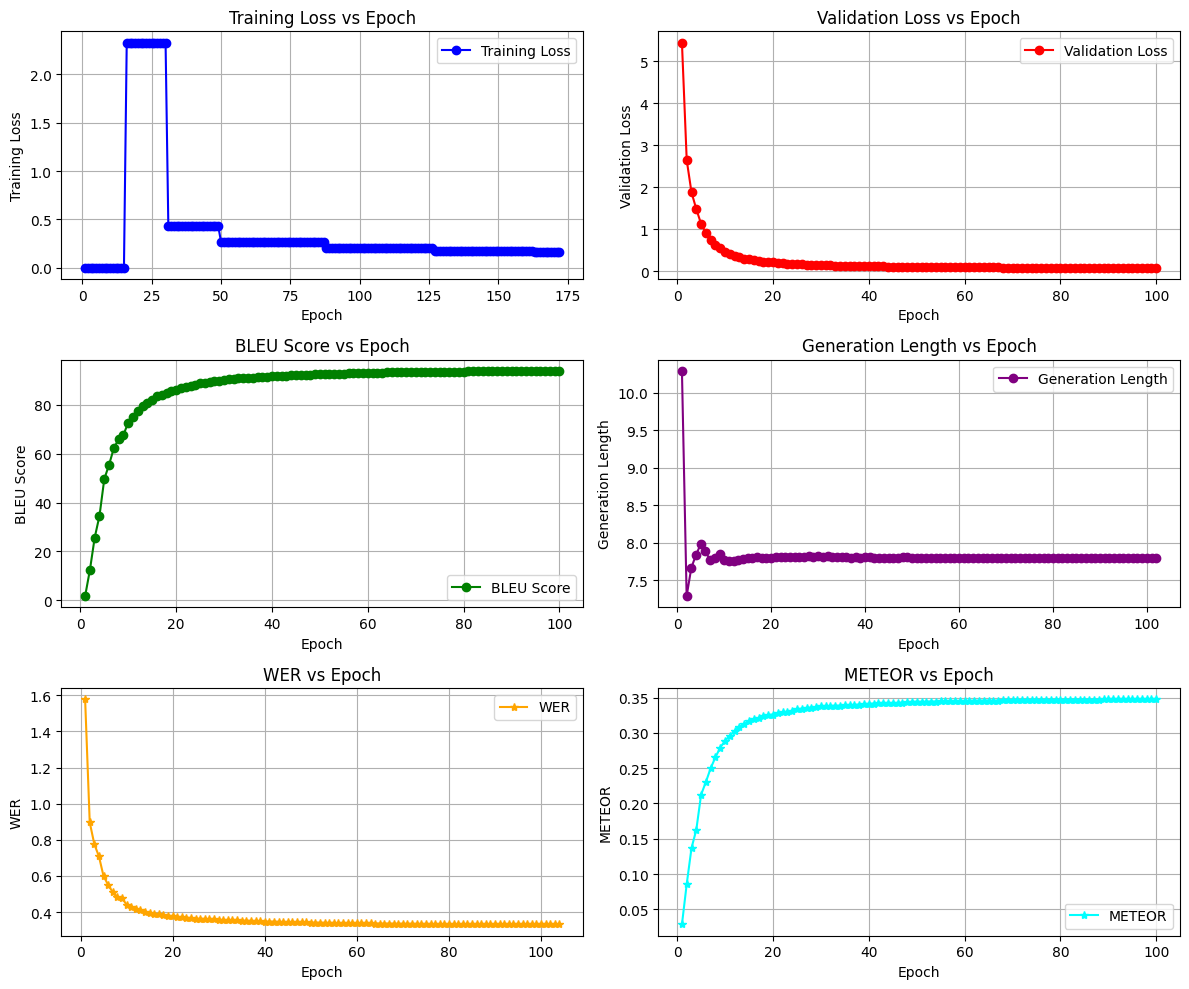

In [ ]:
import matplotlib.pyplot as plt

# Data from the table
epochs = list(range(1, 101))

training_loss = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 2.3294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.4294, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2672, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.2056, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1747, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588, 0.1588]

validation_loss = [5.442694, 2.641792, 1.87438, 1.47736, 1.12528, 0.916235, 0.746921, 0.633417, 0.56198, 0.465648, 0.412392, 0.36772, 0.329405, 0.297574, 0.277914, 0.259614, 0.243332, 0.229312, 0.216186, 0.206423, 0.195229, 0.185802, 0.17742, 0.171656, 0.165559, 0.161265, 0.156285, 0.150729, 0.148455, 0.142435, 0.139082, 0.135618, 0.132138, 0.129351, 0.127653, 0.124319, 0.123147, 0.120099, 0.118374, 0.116756, 0.113836, 0.112404, 0.110665, 0.108913, 0.107388, 0.105742, 0.104767, 0.103567, 0.102157, 0.100803, 0.0993, 0.098315, 0.097017, 0.096312, 0.096358, 0.094334, 0.093677, 0.09352, 0.092676, 0.091564, 0.09169, 0.090012, 0.08962, 0.089505, 0.088261, 0.087624, 0.087473, 0.086597, 0.086583, 0.086093, 0.085856, 0.085107, 0.085303, 0.084231, 0.083957, 0.083532, 0.083165, 0.08296, 0.082484, 0.082283, 0.081912, 0.08148, 0.081418, 0.08135, 0.080883, 0.080943, 0.080629, 0.080602, 0.08045, 0.080176, 0.08029, 0.080012, 0.079825, 0.079842, 0.079727, 0.079818, 0.079729, 0.07977, 0.079756, 0.079771]

bleu = [1.72547, 12.43116, 25.6931, 34.61062, 49.64292, 55.51149, 62.33857, 65.99777, 67.73413, 72.77586, 75.1983, 77.47725, 79.50315, 80.83306, 81.97376, 83.44794, 84.02901, 84.84694, 85.6467, 85.94942, 86.87275, 87.41489, 87.74562, 88.24144, 88.76685, 88.96966, 89.31404, 89.63561, 89.75408, 90.11694, 90.46156, 90.60432, 90.80944, 90.96696, 91.08508, 91.18469, 91.39094, 91.47279, 91.55634, 91.72857, 91.82853, 91.83989, 91.96811, 92.05943, 92.07629, 92.1474, 92.30307, 92.33754, 92.46006, 92.56562, 92.60299, 92.61796, 92.79813, 92.71176, 92.77208, 92.91343, 92.92534, 92.9846, 93.09985, 93.11527, 93.1719, 93.20883, 93.20819, 93.28092, 93.28483, 93.2602, 93.32955, 93.37578, 93.51502, 93.40311, 93.40518, 93.47937, 93.4898, 93.59564, 93.6318, 93.62234, 93.62312, 93.59678, 93.63708, 93.64585, 93.74603, 93.75124, 93.75163, 93.7018, 93.73162, 93.76119, 93.78809, 93.75575, 93.78779, 93.83728, 93.84975, 93.84732, 93.85613, 93.84273, 93.87744, 93.87485, 93.8878, 93.86642, 93.86552, 93.85903]

gen_len = [10.29115, 7.28712, 7.66519, 7.83827, 7.97981, 7.88769, 7.76615, 7.79308, 7.85538, 7.76962, 7.75788, 7.74923, 7.76442, 7.77635, 7.79942, 7.79577, 7.80538, 7.79423, 7.79212, 7.7925, 7.80538, 7.80577, 7.81192, 7.80942, 7.81269, 7.81019, 7.80423, 7.8175, 7.80346, 7.81615, 7.81058, 7.82135, 7.81269, 7.80519, 7.80981, 7.80404, 7.79788, 7.80635, 7.80212, 7.81115, 7.8025, 7.79904, 7.79673, 7.80038, 7.80077, 7.79865, 7.79231, 7.8025, 7.8025, 7.79635, 7.79077, 7.79731, 7.79365, 7.7925, 7.79615, 7.79423, 7.79154, 7.79404, 7.79327, 7.79308, 7.795, 7.79231, 7.79654, 7.79212, 7.79346, 7.79096, 7.78942, 7.79, 7.79077, 7.79308, 7.79442, 7.79365, 7.79365, 7.79558, 7.79481, 7.79442, 7.79615, 7.79615, 7.79481, 7.79404, 7.79269, 7.795, 7.79404, 7.79462, 7.79558, 7.79558, 7.79519, 7.79481, 7.79519, 7.79481, 7.79519, 7.79462, 7.795, 7.79538, 7.79558, 7.79538, 7.79558, 7.79558, 7.79558, 7.79558, 7.79558, 7.79558]

wer = [1.57794, 0.89654, 0.77572, 0.70809, 0.59901, 0.55032, 0.50984, 0.48323, 0.47808, 0.44081, 0.42904, 0.419, 0.4094, 0.40153, 0.39739, 0.39154, 0.38836, 0.38379, 0.37876, 0.3776, 0.3733, 0.3707, 0.36857, 0.36644, 0.36346, 0.36264, 0.36179, 0.35947, 0.35951, 0.35718, 0.35583, 0.35528, 0.35455, 0.35342, 0.35252, 0.35173, 0.35076, 0.34939, 0.34849, 0.34746, 0.34744, 0.34657, 0.34565, 0.34516, 0.34452, 0.34417, 0.34317, 0.34261, 0.34227, 0.34179, 0.34147, 0.34075, 0.34031, 0.34013, 0.33947, 0.33894, 0.33883, 0.33825, 0.33816, 0.33759, 0.33728, 0.33699, 0.33683, 0.33654, 0.33638, 0.33608, 0.33592, 0.33557, 0.33526, 0.33503, 0.33488, 0.33468, 0.33438, 0.33417, 0.33402, 0.33385, 0.33373, 0.33359, 0.33342, 0.33331, 0.33325, 0.33308, 0.33294, 0.33288, 0.33283, 0.33265, 0.33259, 0.33252, 0.33236, 0.33226, 0.3322, 0.33213, 0.33206, 0.33196, 0.3319, 0.33183, 0.33174, 0.33167, 0.33164, 0.33154, 0.33147, 0.33143, 0.33138, 0.33132]

meteor = [
    0.028480, 0.085880, 0.136870, 0.162730, 0.212460, 0.230470, 0.250070, 0.265540,
    0.279310, 0.288900, 0.296280, 0.302820, 0.308400, 0.312270, 0.316830, 0.319560,
    0.321260, 0.323680, 0.325310, 0.326060, 0.327970, 0.329240, 0.330230, 0.331580,
    0.333390, 0.334360, 0.335670, 0.335970, 0.336270, 0.337530, 0.337490, 0.338250,
    0.338530, 0.338620, 0.339200, 0.339520, 0.339790, 0.340090, 0.341250, 0.341040,
    0.341630, 0.341700, 0.342160, 0.342060, 0.342110, 0.342500, 0.343050, 0.343680,
    0.343860, 0.344290, 0.343970, 0.344310, 0.344510, 0.344500, 0.344690, 0.344860,
    0.344820, 0.345020, 0.345250, 0.345360, 0.345480, 0.345690, 0.345620, 0.345850,
    0.345950, 0.345790, 0.345830, 0.346130, 0.346580, 0.346330, 0.346240, 0.346450,
    0.346470, 0.346860, 0.346820, 0.346710, 0.347020, 0.346510, 0.346980, 0.346860,
    0.347030, 0.347110, 0.347200, 0.347110, 0.347170, 0.347210, 0.347250, 0.347110,
    0.347490, 0.347580, 0.347560, 0.347480, 0.347550, 0.347650, 0.347600, 0.347710,
    0.347690, 0.347670, 0.347710, 0.347700
]


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Plot Training Loss
plt.subplot(3, 2, 1)
epochs = list(range(1, len(training_loss)+1))
plt.plot(epochs, training_loss, marker='o', color='blue', label='Training Loss')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.grid(True)
plt.legend()

# Plot Validation Loss
plt.subplot(3, 2, 2)
epochs = list(range(1, len(validation_loss)+1))
plt.plot(epochs, validation_loss, marker='o', color='red', label='Validation Loss')
plt.title('Validation Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.grid(True)
plt.legend()

# Plot BLEU Score
plt.subplot(3, 2, 3)
epochs = list(range(1, len(bleu)+1))
plt.plot(epochs, bleu, marker='o', color='green', label='BLEU Score')
plt.title('BLEU Score vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('BLEU Score')
plt.grid(True)
plt.legend()

# Plot Generation Length
plt.subplot(3, 2, 4)
epochs = list(range(1, len(gen_len)+1))
plt.plot(epochs, gen_len, marker='o', color='purple', label='Generation Length')
plt.title('Generation Length vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Generation Length')
plt.grid(True)
plt.legend()

# Plot WER
plt.subplot(3, 2, 5)
epochs = list(range(1, len(wer)+1))
plt.plot(epochs, wer, marker='*', color='orange', label='WER')
plt.title('WER vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('WER')
plt.grid(True)
plt.legend()

# Plot METEOR
plt.subplot(3, 2, 6)
epochs = list(range(1, len(meteor)+1))
plt.plot(epochs, meteor, marker='*', color='cyan', label='METEOR')
plt.title('METEOR vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('METEOR')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
model_id = "TN_model"
trainer.save_model(model_id )

In [ ]:
# Sort by length
index = val_df["BEFORE"].str.len().sort_values(ascending=False).index
test_df = val_df.reindex(index)

In [ ]:
from transformers import pipeline

pipe = pipeline("text2text-generation", model=model_id)

texts = val_df["BEFORE"].tolist()
tns = pipe(texts, max_length=128, batch_size=16)

In [ ]:
tns

[{'generated_text': 'আমি আমারি মিথ্যে আমার এত আমার এত আমার কি আর আছে আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার আমার'},
 {'generated_text': '। সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশে'},
 {'generated_text': 'তবুও না শিখলে ইয়োরেণ্ডে এইখ না শুধু "ওই শিখি যেী "মঞ্জ "ন আছে । " " জন "শি করেছিলেন শুধু "টি এই " আছে যে শুধু " কি হয় তার " আছে হবে শুধু চাই ও যে জন " একজন শিখে করেছেন " "ন " তা তার " তিনি 

In [ ]:
tns = [tn["generated_text"] for tn in tns]
val_df["AFTER"] = tns
val_df = val_df.sort_index()
val_df.head()

,BEFORE,AFTER
0,সত্যিই আমার প্রথমবার কেউ দেখতে এখনো এত খুশি ঘু...,আমি আমারি মিথ্যে আমার এত আমার এত আমার কি আর আছ...
1,সারা দেশে এমন একটা আতঙ্কের পরিবেশ সৃষ্টি করে র...,। সারা দেশে । সারা দেশে । সারা দেশে । সারা দেশ...
2,তিনি শিখেছিলেন যে যদি কেউ যিহোবাকে খুশি করতে চ...,"তবুও না শিখলে ইয়োরেণ্ডে এইখ না শুধু ""ওই শিখি ..."
3,"কিন্তু , যারা ঈশ্বরকে খুশি করতে চান তারা জানেন...","করতে হলে যারা খ্রীষ্টান তারা জানেন যে, যারা খ্..."
4,আকাশে মেঘ উড়ে বেড়ায় । হিমালয়ে যাওয়ার আগে ঐ মেঘ...,হিমালয়ের কোন হিমালয়ের মেঘ হিমালয় হিমালয়ের ...


In [ ]:
from transformers import AutoTokenizer
from transformers import AutoModelForSeq2SeqLM

In [ ]:
text = "Unnormalized Text to Normalaized Text: ১১০০০৫-৩৯০০১২১=৬৫০০০০২৯"

In [ ]:
# checkpoint-2500
tokenizer = AutoTokenizer.from_pretrained("checkpoint-1500")
inputs = tokenizer(text, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

OSError: checkpoint-1500 is not a local folder and is not a valid model identifier listed on 'https://huggingface.co/models'
If this is a private repository, make sure to pass a token having permission to this repo either by logging in with `huggingface-cli login` or by passing `token=<your_token>`

In [ ]:
# checkpoint-3000
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-1000")
inputs = tokenizer(text, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1000")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# checkpoint-3500
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-500")
inputs = tokenizer(text, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
text2 = "Unnormalized Text to Normalaized Text: ১১-০৯-১৯৯৬"

In [ ]:
# checkpoint-2500
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-1500")
inputs = tokenizer(text2, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# checkpoint-3000
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-500")
inputs = tokenizer(text2, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# checkpoint-3500
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-1000")
inputs = tokenizer(text2, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1000")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
text3 = "Unnormalized Text to Normalaized Text: ৭৭৭৪৪২.৮৮৮৮৭৬২%"

In [ ]:
# checkpoint-2500
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-1500")
inputs = tokenizer(text3, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# checkpoint-3000
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-500")
inputs = tokenizer(text3, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-500")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)

In [ ]:
# checkpoint-3500
tokenizer = AutoTokenizer.from_pretrained("model/checkpoint-1000")
inputs = tokenizer(text3, return_tensors="pt").input_ids
model = AutoModelForSeq2SeqLM.from_pretrained("model/checkpoint-1000")
outputs = model.generate(inputs, max_new_tokens=40, do_sample=True, top_k=30, top_p=0.95)
tokenizer.decode(outputs[0], skip_special_tokens=True)